<b>Example 1: Iris Dataset</b>

---

Step 0: Setting Environment

In [3]:
# Import libraries
import numpy as np                                      
import pandas as pd                                     
import matplotlib.pyplot as plt                         

from sklearn.tree import DecisionTreeClassifier         
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate  
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score  
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

---

Step 1: Prepare Dataset

In [4]:
df_main = pd.read_csv("iris.csv")
df_main.head()

,sepal_length,sepal_width,petal_length,petal_width,iris_class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df_main.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
iris_class          str
dtype: object

In [6]:
mapping = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}

df_main['iris_class'] = df_main['iris_class'].map(mapping)
df_main.head()

,sepal_length,sepal_width,petal_length,petal_width,iris_class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df_main.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
iris_class        int64
dtype: object

---

Step 2: Split all data into (1)training data and (2)test data

In [8]:
X = df_main.iloc[:, 0:4]
y = df_main.iloc[:, 4]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

---

Step 3: Find the best hyper-parameters

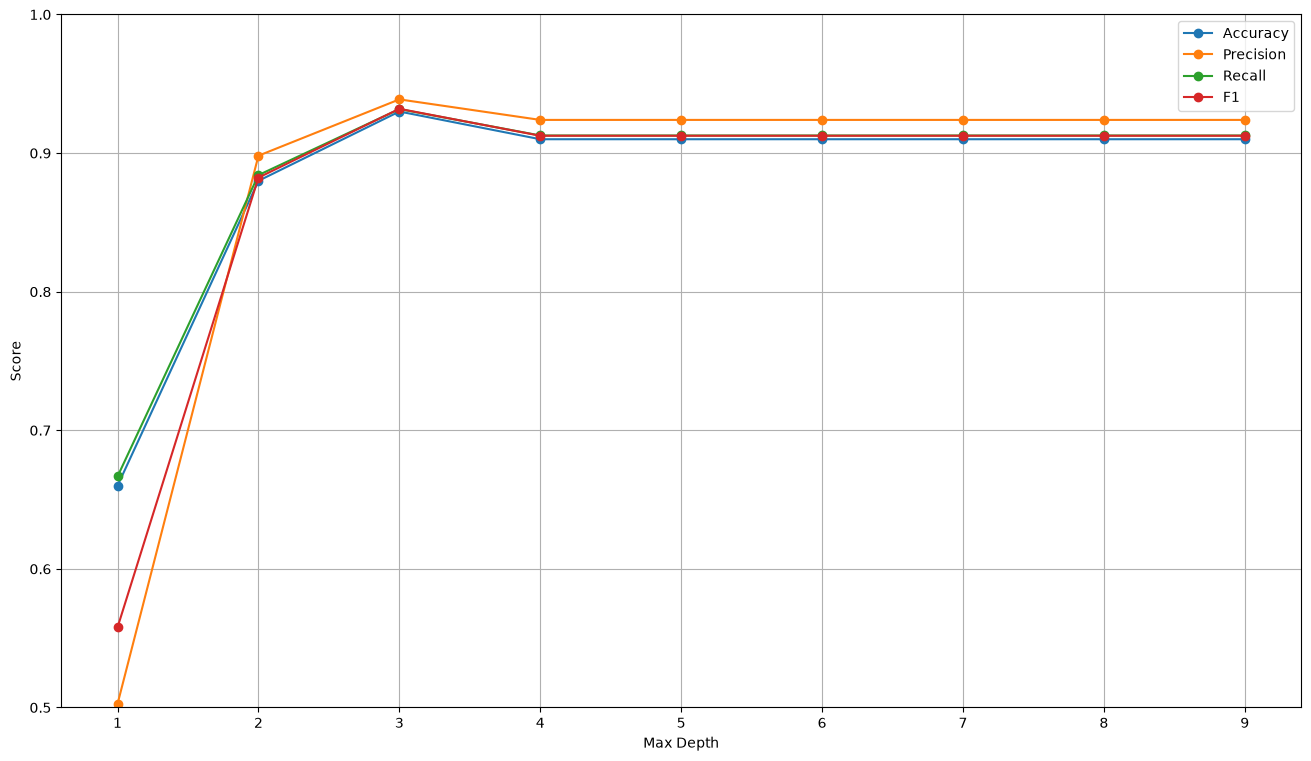

In [9]:
# Observe max_depth
max_depth = []
accuracy = []
precision = []
recall = []
f1_macro = []

# Observe algorithm
criterion = 'gini'
#criterion = 'entropy'

for i in range(1, 10):
    clf = DecisionTreeClassifier(criterion=criterion, max_depth=i, random_state=42)
    scoring = {
        'accuracy': 'accuracy',
        'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
        'recall_macro': make_scorer(recall_score, average='macro', zero_division=0),
        'f1_macro': make_scorer(f1_score, average='macro', zero_division=0)
    }
    scores = cross_validate(clf, X_train, y_train, cv=5, scoring=scoring)

    max_depth.append(i)
    accuracy.append(scores['test_accuracy'].mean())
    precision.append(scores['test_precision_macro'].mean())
    recall.append(scores['test_recall_macro'].mean())
    f1_macro.append(scores['test_f1_macro'].mean())


fig, ax = plt.subplots(figsize=(16, 9))
ax.plot(max_depth, accuracy, marker='o')
ax.plot(max_depth, precision, marker='o')
ax.plot(max_depth, recall, marker='o')
ax.plot(max_depth, f1_macro, marker='o')

ax.legend(['Accuracy', 'Precision', 'Recall', 'F1'])
ax.set_xlabel("Max Depth")
ax.set_ylabel("Score")
ax.set_ylim([0.5, 1])
ax.grid()
plt.show()

---

Step 4: Create model with best parameters

In [10]:
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X_train, y_train);

---

Step 5: Test model

Accuracy = 0.98
Precision = [1.     0.9375 1.    ]
Recall = [1.     1.     0.9375]
F1 = [1.         0.96774194 0.96774194]


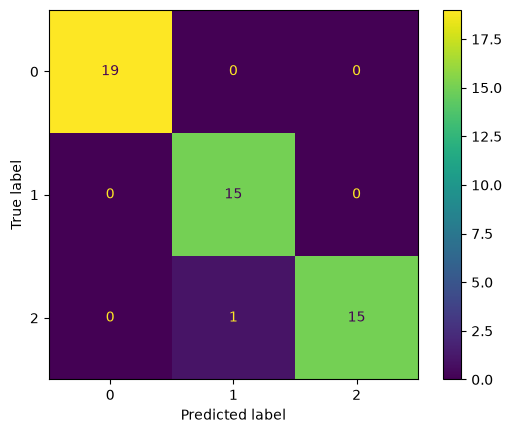

In [11]:
y_pred = clf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(cm).plot()

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average=None, zero_division=0)
recall = recall_score(y_test, y_pred, average=None, zero_division=0)
f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

print("Accuracy =", accuracy)
print("Precision =", precision)
print("Recall =", recall)
print("F1 =", f1)

---

Step 6: Visualized Model

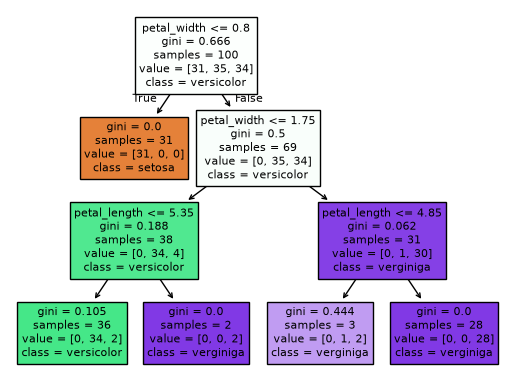

In [12]:
from sklearn import tree

tree.plot_tree(clf,
               feature_names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
               class_names=['setosa', 'versicolor', 'verginiga'],
               filled=True)
plt.show()